# **Data** **Exploration**

First 5 Rows:
   age  gender    bmi  children smoker     region medical_history  \
0   46    male  21.45         5    yes  southeast        Diabetes   
1   25  female  25.38         2    yes  northwest        Diabetes   
2   38    male  44.88         2    yes  southwest             NaN   
3   25    male  19.89         0     no  northwest             NaN   
4   49    male  38.21         3    yes  northwest        Diabetes   

  family_medical_history exercise_frequency    occupation coverage_level  \
0                    NaN              Never   Blue collar        Premium   
1    High blood pressure       Occasionally  White collar        Premium   
2    High blood pressure       Occasionally   Blue collar        Premium   
3               Diabetes             Rarely  White collar       Standard   
4    High blood pressure             Rarely  White collar       Standard   

        charges  
0  20460.307669  
1  20390.899218  
2  20204.476302  
3  11789.029843  
4  19268.309838  

Datas

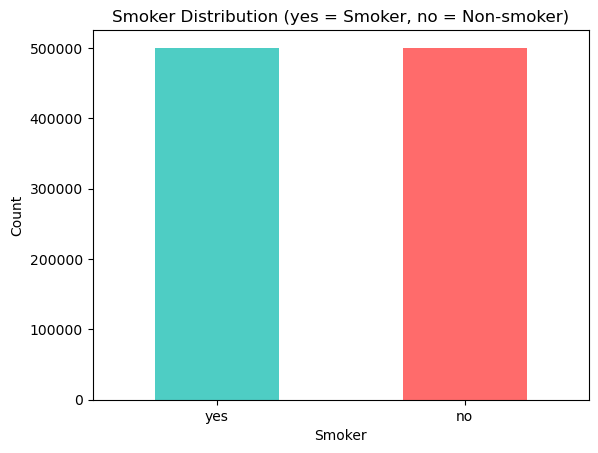

In [6]:
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.colors import ListedColormap
import numpy as np
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import confusion_matrix, accuracy_score, precision_score, recall_score

# Load the dataset (Insurance Charges Dataset)
df = pd.read_csv("insurance_dataset.csv")

# Remove unnecessary unnamed index columns
df = df.loc[:, ~df.columns.str.contains('^Unnamed')]

# Remove extra spaces from column names
df.columns = df.columns.str.strip()

# Display first rows
print("First 5 Rows:")
print(df.head())

# Display dataset shape
print("\nDataset Shape:")
print(df.shape)

# Display dataset information
print("\nDataset Info:")
print(df.info())

# Display column names
print("\nColumns:")
print(df.columns)

# Statistical summary
print("\nStatistical Summary:")
print(df.describe(include='all'))

# Check missing values
print("\nMissing Values:")
print(df.isnull().sum())

# Check duplicate rows
print("\nDuplicate Rows:")
print(df.duplicated().sum())

# Check target column distribution
print("\nSmoker Distribution:")
print(df['smoker'].value_counts())
print("\nSmoker Percentage:")
print(df['smoker'].value_counts(normalize=True) * 100)

# Visualize target distribution
df['smoker'].value_counts().plot(kind='bar', color=['#4ECDC4', '#FF6B6B'])
plt.title("Smoker Distribution (yes = Smoker, no = Non-smoker)")
plt.xlabel("Smoker")
plt.ylabel("Count")
plt.xticks(rotation=0)
plt.show()




# **Data** **Cleaning**

In [2]:
# Remove duplicate rows
df = df.drop_duplicates()

# Remove unnecessary columns for classification
columns_to_drop = []  # No id column to drop in this dataset
df = df.drop(columns=columns_to_drop, errors='ignore')

# Handle missing values in numerical columns using median
numeric_cols = df.select_dtypes(include=['int64', 'float64']).columns
for col in numeric_cols:
    df[col] = df[col].fillna(df[col].median())

# Handle missing values in categorical columns using mode
categorical_cols = df.select_dtypes(include=['object']).columns
for col in categorical_cols:
    df[col] = df[col].fillna(df[col].mode()[0])

# Make sure the target column exists
print("Target Column:")
print(df['smoker'].value_counts())

# Final check after cleaning
print("\nMissing Values After Cleaning:")
print(df.isnull().sum())

print("\nDataset Shape After Cleaning:")
print(df.shape)

print("\nColumns After Cleaning:")
print(df.columns)

print("\nCleaned Data Sample:")
print(df.head())

# Detect outliers using IQR for the key numeric features
print("\nOutlier counts per numeric feature (IQR method):")
for col in ['age', 'bmi', 'children', 'charges']:
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1
    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR
    n_out = ((df[col] < lower) | (df[col] > upper)).sum()
    print(f"  {col}: {n_out} outliers")


Target Column:
smoker
yes    500129
no     499871
Name: count, dtype: int64

Missing Values After Cleaning:
age                       0
gender                    0
bmi                       0
children                  0
smoker                    0
region                    0
medical_history           0
family_medical_history    0
exercise_frequency        0
occupation                0
coverage_level            0
charges                   0
dtype: int64

Dataset Shape After Cleaning:
(1000000, 12)

Columns After Cleaning:
Index(['age', 'gender', 'bmi', 'children', 'smoker', 'region',
       'medical_history', 'family_medical_history', 'exercise_frequency',
       'occupation', 'coverage_level', 'charges'],
      dtype='object')

Cleaned Data Sample:
   age  gender    bmi  children smoker     region medical_history  \
0   46    male  21.45         5    yes  southeast        Diabetes   
1   25  female  25.38         2    yes  northwest        Diabetes   
2   38    male  44.88         2   


--- Logistic Regression Results ---
Confusion Matrix:
[[74976 24998]
 [26040 73986]]
Accuracy Score: 74.48%
Precision Score: 74.75%
Recall Score: 73.97%


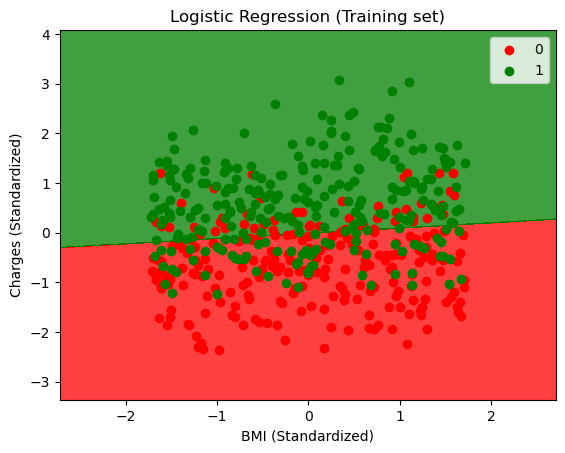

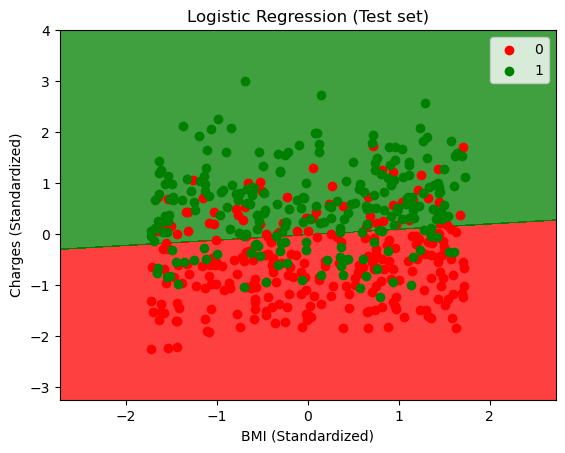

In [3]:
# --- LOGISTIC REGRESSION SECTION ---

# 1. Preprocessing for Logistic Regression
# Convert Target variable (smoker) to binary numeric values: yes=1 (Smoker), no=0 (Non-smoker)
if df['smoker'].dtype == 'object':
    df['smoker'] = df['smoker'].apply(lambda x: 1 if x == 'yes' else 0)

# Select features (X) and target (y) — using two top correlated features for visualization
X = df[['bmi', 'charges']].values
y = df['smoker'].values

# 2. Splitting the dataset (80% Training, 20% Test)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.20, random_state=0, stratify=y)

# 3. Feature Scaling
sc = StandardScaler()
X_train = sc.fit_transform(X_train)
X_test = sc.transform(X_test)

# 4. Training the Logistic Regression model
classifier = LogisticRegression(random_state=0, class_weight='balanced', max_iter=1000)
classifier.fit(X_train, y_train)

# 5. Predicting Test set results
y_pred = classifier.predict(X_test)

# 6. Model Evaluation
from sklearn.metrics import precision_score, recall_score
cm = confusion_matrix(y_test, y_pred)
accuracy = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred)
recall = recall_score(y_test, y_pred)

print("\n--- Logistic Regression Results ---")
print("Confusion Matrix:")
print(cm)
print(f"Accuracy Score: {accuracy * 100:.2f}%")
print(f"Precision Score: {precision * 100:.2f}%")
print(f"Recall Score: {recall * 100:.2f}%")

# 7. Visualization of Results
def plot_results(X_set, y_set, title):
    if len(X_set) > 500:
        indices = np.random.choice(len(X_set), 500, replace=False)
        X_set_plot, y_set_plot = X_set[indices], y_set[indices]
    else:
        X_set_plot, y_set_plot = X_set, y_set

    X1, X2 = np.meshgrid(np.arange(start=X_set_plot[:, 0].min() - 1, stop=X_set_plot[:, 0].max() + 1, step=0.01),
                         np.arange(start=X_set_plot[:, 1].min() - 1, stop=X_set_plot[:, 1].max() + 1, step=0.01))

    plt.contourf(X1, X2, classifier.predict(np.array([X1.ravel(), X2.ravel()]).T).reshape(X1.shape),
                 alpha=0.75, cmap=ListedColormap(('red', 'green')))

    for i, j in enumerate(np.unique(y_set_plot)):
        plt.scatter(X_set_plot[y_set_plot == j, 0], X_set_plot[y_set_plot == j, 1],
                    color=np.array([ListedColormap(('red', 'green'))(i)]), label=j)

    plt.title(title)
    plt.xlabel('BMI (Standardized)')
    plt.ylabel('Charges (Standardized)')
    plt.legend()
    plt.show()

# Visualize both Training and Test sets
plot_results(X_train, y_train, 'Logistic Regression (Training set)')
plot_results(X_test, y_test, 'Logistic Regression (Test set)')


Class distribution:
smoker
1    500129
0    499871
Name: count, dtype: int64
Number of features used: 20
Subsampled to 15000 rows for SVM training (stratified).

=== Confusion Matrices ===

Linear:
 [[1487  388]
 [ 333 1542]]

RBF:
 [[1497  378]
 [ 363 1512]]

Polynomial:
 [[1505  370]
 [ 336 1539]]

=== Accuracy Scores ===
Linear     Accuracy: 80.77%
RBF        Accuracy: 80.24%
Polynomial Accuracy: 81.17%

=== Classification Reports ===
Linear:
               precision    recall  f1-score   support

           0       0.82      0.79      0.80      1875
           1       0.80      0.82      0.81      1875

    accuracy                           0.81      3750
   macro avg       0.81      0.81      0.81      3750
weighted avg       0.81      0.81      0.81      3750

RBF:
               precision    recall  f1-score   support

           0       0.80      0.80      0.80      1875
           1       0.80      0.81      0.80      1875

    accuracy                           0.80      375

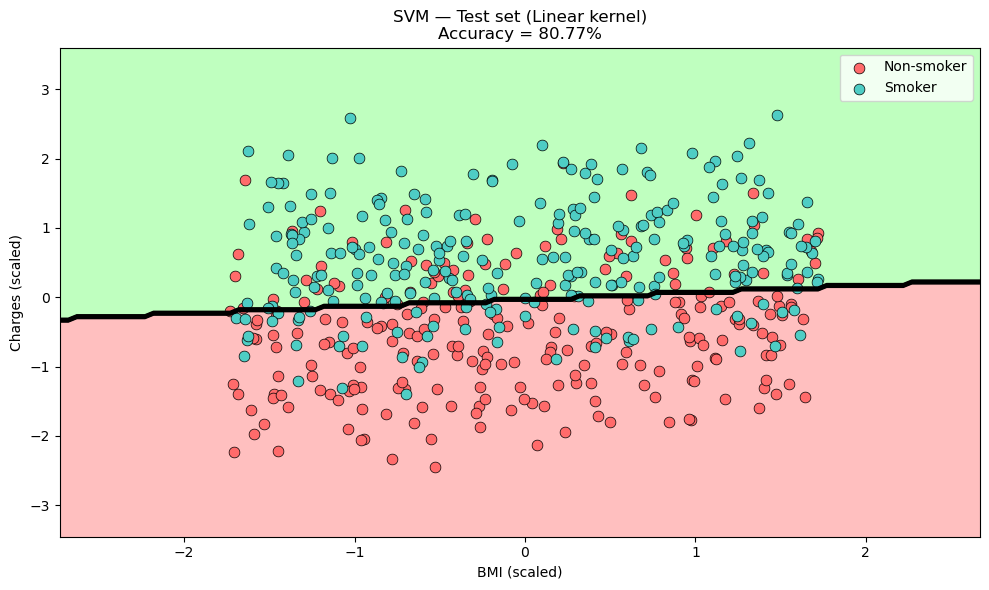

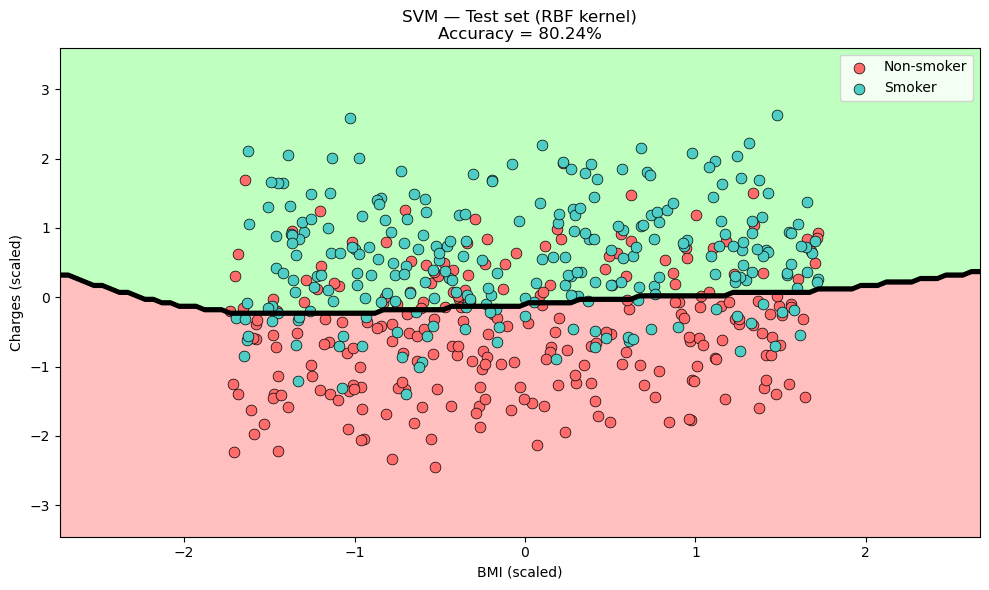

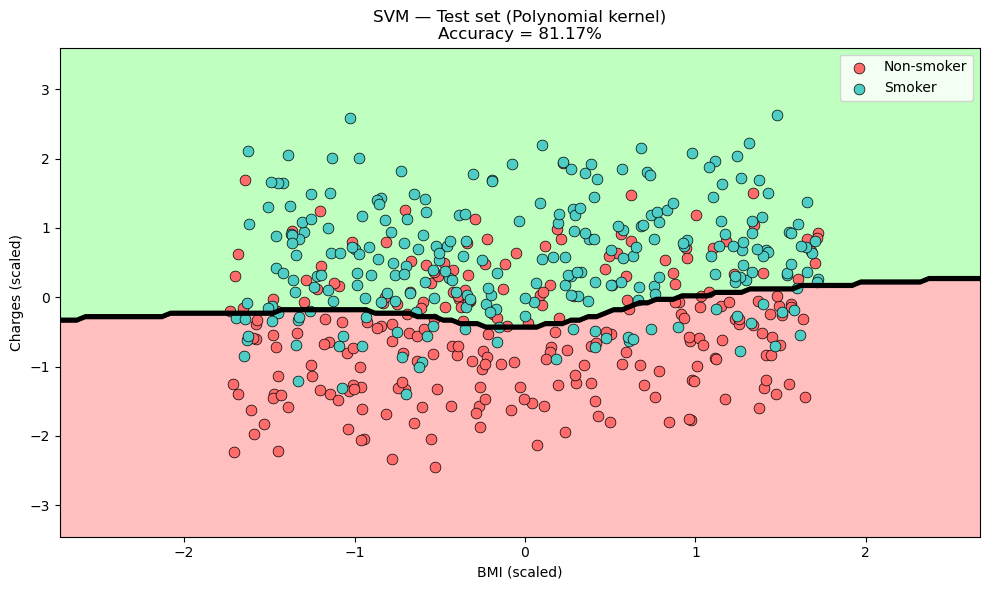

In [4]:
# --- SVM SECTION (Linear, RBF, Polynomial) ---
# Target: smoker (binary: yes=1 Smoker, no=0 Non-smoker)

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.colors import ListedColormap
from sklearn.preprocessing    import StandardScaler, LabelEncoder
from sklearn.model_selection  import train_test_split, StratifiedShuffleSplit
from sklearn.svm              import SVC, LinearSVC
from sklearn.metrics          import (confusion_matrix, accuracy_score,
                                      precision_score, recall_score,
                                      classification_report)

# 1. Re-load + clean
df_svm = pd.read_csv('insurance_dataset.csv')
df_svm = df_svm.loc[:, ~df_svm.columns.str.contains('^Unnamed')]
df_svm.columns = df_svm.columns.str.strip()
df_svm = df_svm.drop_duplicates()
for col in df_svm.select_dtypes(include=['int64','float64']).columns:
    df_svm[col] = df_svm[col].fillna(df_svm[col].median())
for col in df_svm.select_dtypes(include=['object']).columns:
    df_svm[col] = df_svm[col].fillna(df_svm[col].mode()[0])

# Encode target: yes=1, no=0
df_svm['smoker'] = df_svm['smoker'].apply(lambda x: 1 if x == 'yes' else 0)

# One-hot encode the remaining categorical features
categorical_features = ['gender', 'region', 'medical_history', 'family_medical_history',
                        'exercise_frequency', 'occupation', 'coverage_level']
df_svm = pd.get_dummies(df_svm, columns=categorical_features, drop_first=True)

print('Class distribution:')
print(df_svm['smoker'].value_counts())

feature_cols = [c for c in df_svm.columns if c != 'smoker']
print('Number of features used:', len(feature_cols))

# 1M rows is too many for RBF/Polynomial SVM (O(n^2) memory). Subsample
# stratified to keep the comparison across kernels fair and tractable.
SVM_SAMPLE = 15000
sss = StratifiedShuffleSplit(n_splits=1, train_size=SVM_SAMPLE, random_state=0)
sample_idx, _ = next(sss.split(df_svm[feature_cols], df_svm['smoker']))
df_svm_s = df_svm.iloc[sample_idx].reset_index(drop=True)
print(f'Subsampled to {len(df_svm_s)} rows for SVM training (stratified).')

X = df_svm_s[feature_cols].values
y = df_svm_s['smoker'].values

# 2. Train / test split (75 / 25)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.25, random_state=0, stratify=y
)

# 3. Feature scaling
sc = StandardScaler()
X_train = sc.fit_transform(X_train)
X_test  = sc.transform(X_test)

# 4. Train models
clf_linear = LinearSVC(C=5, max_iter=5000, random_state=0)
clf_rbf    = SVC(kernel='rbf',  C=10, gamma='scale', random_state=0)
clf_poly   = SVC(kernel='poly', C=5,  degree=3,      random_state=0)

clf_linear.fit(X_train, y_train)
clf_rbf.fit(X_train,    y_train)
clf_poly.fit(X_train,   y_train)

# 5. Predictions
y_pred_linear = clf_linear.predict(X_test)
y_pred_rbf    = clf_rbf.predict(X_test)
y_pred_poly   = clf_poly.predict(X_test)

cm_linear = confusion_matrix(y_test, y_pred_linear)
cm_rbf    = confusion_matrix(y_test, y_pred_rbf)
cm_poly   = confusion_matrix(y_test, y_pred_poly)

print('\n=== Confusion Matrices ===')
print('\nLinear:\n',     cm_linear)
print('\nRBF:\n',        cm_rbf)
print('\nPolynomial:\n', cm_poly)

acc_linear = accuracy_score(y_test, y_pred_linear)
acc_rbf    = accuracy_score(y_test, y_pred_rbf)
acc_poly   = accuracy_score(y_test, y_pred_poly)

print('\n=== Accuracy Scores ===')
print(f'Linear     Accuracy: {acc_linear * 100:.2f}%')
print(f'RBF        Accuracy: {acc_rbf    * 100:.2f}%')
print(f'Polynomial Accuracy: {acc_poly   * 100:.2f}%')

print('\n=== Classification Reports ===')
print('Linear:\n',     classification_report(y_test, y_pred_linear))
print('RBF:\n',        classification_report(y_test, y_pred_rbf))
print('Polynomial:\n', classification_report(y_test, y_pred_poly))

results = {'Linear': acc_linear, 'RBF': acc_rbf, 'Polynomial': acc_poly}
best_kernel = max(results, key=results.get)
print(f'Best Kernel: {best_kernel} ({results[best_kernel]*100:.2f}%)')

# 6. Visualization using top 2 correlated features (bmi vs charges)
top_features = ['bmi', 'charges']
X_vis = df_svm_s[top_features].values
X_vis_train, X_vis_test, y_vis_train, y_vis_test = train_test_split(
    X_vis, y, test_size=0.25, random_state=0, stratify=y
)
sc_vis = StandardScaler()
X_vis_train = sc_vis.fit_transform(X_vis_train)
X_vis_test  = sc_vis.transform(X_vis_test)

clf_linear_vis = SVC(kernel='linear', C=5,  random_state=0)
clf_rbf_vis    = SVC(kernel='rbf',    C=10, gamma='scale', random_state=0)
clf_poly_vis   = SVC(kernel='poly',   C=5,  degree=3,      random_state=0)
clf_linear_vis.fit(X_vis_train, y_vis_train)
clf_rbf_vis.fit(X_vis_train,    y_vis_train)
clf_poly_vis.fit(X_vis_train,   y_vis_train)

def plot_svm(clf, X_set, y_set, title):
    if len(X_set) > 500:
        rng = np.random.default_rng(0)
        idx = rng.choice(len(X_set), 500, replace=False)
        X_set, y_set = X_set[idx], y_set[idx]
    X1, X2 = np.meshgrid(
        np.arange(start=X_set[:, 0].min() - 1, stop=X_set[:, 0].max() + 1, step=0.05),
        np.arange(start=X_set[:, 1].min() - 1, stop=X_set[:, 1].max() + 1, step=0.05)
    )
    plt.figure(figsize=(10, 6))
    plt.contourf(
        X1, X2,
        clf.predict(np.array([X1.ravel(), X2.ravel()]).T).reshape(X1.shape),
        alpha=0.75, cmap=ListedColormap(('#FFAAAA', '#AAFFAA'))
    )
    plt.contour(X1, X2,
        clf.predict(np.array([X1.ravel(), X2.ravel()]).T).reshape(X1.shape),
        colors='black', linewidths=1.5)
    plt.xlim(X1.min(), X1.max())
    plt.ylim(X2.min(), X2.max())
    for i, j in enumerate(np.unique(y_set)):
        plt.scatter(
            X_set[y_set == j, 0], X_set[y_set == j, 1],
            c=[ListedColormap(('#FF6B6B', '#4ECDC4'))(i)],
            label=('Non-smoker' if j==0 else 'Smoker'), s=60, edgecolors='k', linewidths=0.5
        )
    plt.title(title)
    plt.xlabel('BMI (scaled)')
    plt.ylabel('Charges (scaled)')
    plt.legend()
    plt.tight_layout()
    plt.show()

plot_svm(clf_linear_vis, X_vis_test, y_vis_test, f'SVM — Test set (Linear kernel)\nAccuracy = {acc_linear*100:.2f}%')
plot_svm(clf_rbf_vis,    X_vis_test, y_vis_test, f'SVM — Test set (RBF kernel)\nAccuracy = {acc_rbf*100:.2f}%')
plot_svm(clf_poly_vis,   X_vis_test, y_vis_test, f'SVM — Test set (Polynomial kernel)\nAccuracy = {acc_poly*100:.2f}%')


Class distribution:
smoker
1    500129
0    499871
Name: count, dtype: int64
Number of features used: 20
Random Forest Accuracy: 80.79%

Confusion Matrix:
[[120416  29545]
 [ 28079 121960]]

Classification Report:
              precision    recall  f1-score   support

           0       0.81      0.80      0.81    149961
           1       0.80      0.81      0.81    150039

    accuracy                           0.81    300000
   macro avg       0.81      0.81      0.81    300000
weighted avg       0.81      0.81      0.81    300000


Top 10 Feature Importances:
charges                                       53.94%
bmi                                           10.82%
age                                            8.35%
coverage_level_Premium                         7.41%
children                                       3.46%
medical_history_Heart disease                  2.40%
family_medical_history_Heart disease           2.32%
coverage_level_Standard                        1.78%
gender

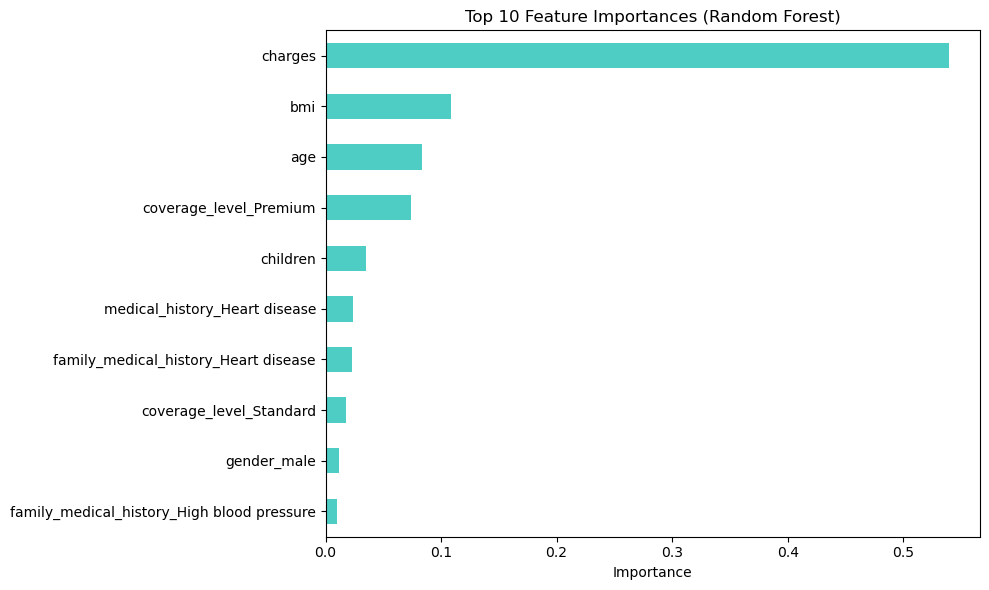

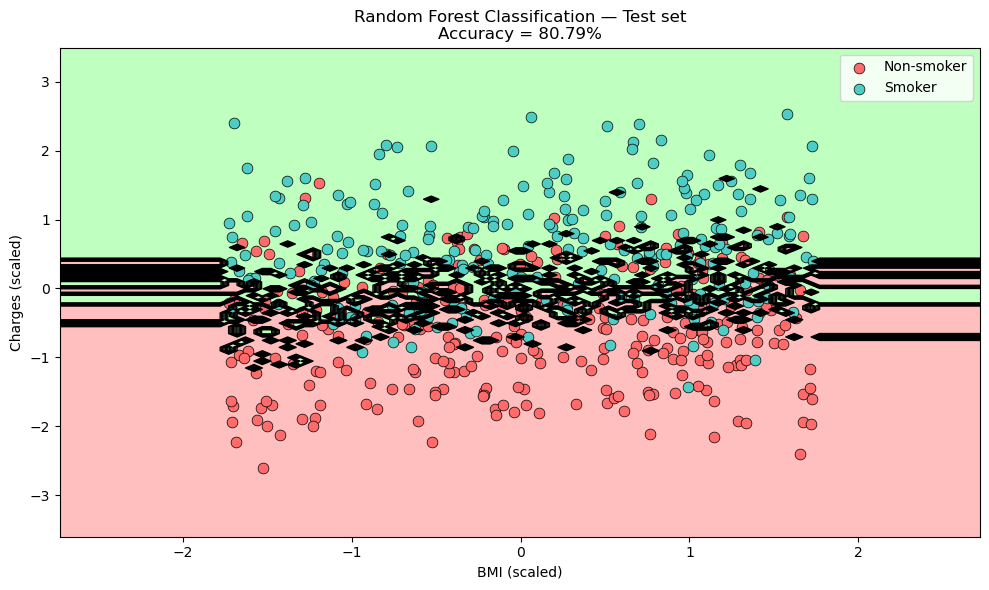

In [5]:
# --- RANDOM FOREST SECTION ---
# Target: smoker (binary: yes=1 Smoker, no=0 Non-smoker)

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.colors import ListedColormap
from sklearn.preprocessing   import StandardScaler, LabelEncoder
from sklearn.model_selection  import train_test_split
from sklearn.ensemble         import RandomForestClassifier
from sklearn.metrics          import (confusion_matrix, accuracy_score,
                                      classification_report)

# 1. Re-load + clean
df_rf = pd.read_csv('insurance_dataset.csv')
df_rf = df_rf.loc[:, ~df_rf.columns.str.contains('^Unnamed')]
df_rf.columns = df_rf.columns.str.strip()
df_rf = df_rf.drop_duplicates()
for col in df_rf.select_dtypes(include=['int64','float64']).columns:
    df_rf[col] = df_rf[col].fillna(df_rf[col].median())
for col in df_rf.select_dtypes(include=['object']).columns:
    df_rf[col] = df_rf[col].fillna(df_rf[col].mode()[0])

# Encode target: yes=1, no=0
df_rf['smoker'] = df_rf['smoker'].apply(lambda x: 1 if x == 'yes' else 0)

# One-hot encode the remaining categorical features
categorical_features = ['gender', 'region', 'medical_history', 'family_medical_history',
                        'exercise_frequency', 'occupation', 'coverage_level']
df_rf = pd.get_dummies(df_rf, columns=categorical_features, drop_first=True)

print('Class distribution:')
print(df_rf['smoker'].value_counts())

feature_cols = [c for c in df_rf.columns if c != 'smoker']
print('Number of features used:', len(feature_cols))

X = df_rf[feature_cols].values
y = df_rf['smoker'].values

# 2. Train / test split (70 / 30)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.30, random_state=0, stratify=y
)

# 3. Feature scaling
sc = StandardScaler()
X_train = sc.fit_transform(X_train)
X_test  = sc.transform(X_test)

# 4. Train Random Forest
classifier = RandomForestClassifier(
    n_estimators=200,
    max_depth=None,
    min_samples_leaf=2,
    criterion='entropy',
    n_jobs=-1,
    random_state=0
)
classifier.fit(X_train, y_train)
y_pred = classifier.predict(X_test)

# 5. Accuracy
acc = accuracy_score(y_test, y_pred)
print(f'Random Forest Accuracy: {acc * 100:.2f}%')

# 6. Confusion matrix + classification report
cm = confusion_matrix(y_test, y_pred)
print('\nConfusion Matrix:')
print(cm)
print('\nClassification Report:')
print(classification_report(y_test, y_pred))

# 7. Feature importances
importances = classifier.feature_importances_
feat_imp = pd.Series(importances, index=feature_cols).sort_values(ascending=False)
print('\nTop 10 Feature Importances:')
print(feat_imp.head(10).apply(lambda x: f'{x*100:.2f}%'))

# Plot top 10 feature importances
plt.figure(figsize=(10, 6))
feat_imp.head(10).plot(kind='barh', color='#4ECDC4')
plt.gca().invert_yaxis()
plt.title('Top 10 Feature Importances (Random Forest)')
plt.xlabel('Importance')
plt.tight_layout()
plt.show()

# 8. Visualize using top 2 correlated features (bmi vs charges)
top_features = ['bmi', 'charges']
X_vis = df_rf[top_features].values
X_vis_train, X_vis_test, y_vis_train, y_vis_test = train_test_split(
    X_vis, y, test_size=0.30, random_state=0, stratify=y
)
sc_vis = StandardScaler()
X_vis_train = sc_vis.fit_transform(X_vis_train)
X_vis_test  = sc_vis.transform(X_vis_test)

clf_vis = RandomForestClassifier(
    n_estimators=200,
    max_depth=None,
    min_samples_leaf=2,
    criterion='entropy',
    n_jobs=-1,
    random_state=0
)
clf_vis.fit(X_vis_train, y_vis_train)

X_set, y_set = X_vis_test, y_vis_test
if len(X_set) > 500:
    rng = np.random.default_rng(0)
    idx = rng.choice(len(X_set), 500, replace=False)
    X_set, y_set = X_set[idx], y_set[idx]

X1, X2 = np.meshgrid(
    np.arange(start=X_set[:, 0].min() - 1, stop=X_set[:, 0].max() + 1, step=0.05),
    np.arange(start=X_set[:, 1].min() - 1, stop=X_set[:, 1].max() + 1, step=0.05)
)
plt.figure(figsize=(10, 6))
plt.contourf(
    X1, X2,
    clf_vis.predict(np.array([X1.ravel(), X2.ravel()]).T).reshape(X1.shape),
    alpha=0.75, cmap=ListedColormap(('#FFAAAA', '#AAFFAA'))
)
plt.contour(
    X1, X2,
    clf_vis.predict(np.array([X1.ravel(), X2.ravel()]).T).reshape(X1.shape),
    colors='black', linewidths=1.0
)
plt.xlim(X1.min(), X1.max())
plt.ylim(X2.min(), X2.max())
for i, j in enumerate(np.unique(y_set)):
    plt.scatter(
        X_set[y_set == j, 0], X_set[y_set == j, 1],
        c=[ListedColormap(('#FF6B6B', '#4ECDC4'))(i)],
        label=('Non-smoker' if j==0 else 'Smoker'), s=60, edgecolors='k', linewidths=0.5
    )
plt.title(f'Random Forest Classification — Test set\nAccuracy = {acc*100:.2f}%')
plt.xlabel('BMI (scaled)')
plt.ylabel('Charges (scaled)')
plt.legend()
plt.tight_layout()
plt.show()
